第一个版本的代码

In [ ]:
package com.company.mapping;

import java.io.FileInputStream;
import java.io.FileOutputStream;
import java.io.InputStream;
import java.io.OutputStream;
import java.util.Map;

import javax.xml.stream.XMLInputFactory;
import javax.xml.stream.XMLOutputFactory;
import javax.xml.stream.XMLStreamConstants;
import javax.xml.stream.XMLStreamReader;
import javax.xml.stream.XMLStreamWriter;

import com.sap.aii.mapping.api.AbstractTransformation;
import com.sap.aii.mapping.api.StreamTransformationException;
import com.sap.aii.mapping.api.TransformationInput;
import com.sap.aii.mapping.api.TransformationOutput;

public class JM_SecondJavaMapping extends AbstractTransformation {

    @Override
    public void transform(TransformationInput in, TransformationOutput out) throws StreamTransformationException {
        try {
            execute(in.getInputPayload().getInputStream(), out.getOutputPayload().getOutputStream());
        } catch (Exception ee) {
            throw new StreamTransformationException("Mapping failed: " + ee.getMessage(), ee);
        }
    }

    public void execute(InputStream in, OutputStream out) throws StreamTransformationException {
        try {
            XMLInputFactory factory = XMLInputFactory.newInstance();
            XMLStreamReader reader = factory.createXMLStreamReader(in);
            XMLOutputFactory outFactory = XMLOutputFactory.newInstance();
            XMLStreamWriter writer = outFactory.createXMLStreamWriter(out, "UTF-8");

            writer.writeStartDocument("UTF-8", "1.0");

            String currentElement = null;  // 记录当前正在处理的元素名

            while (reader.hasNext()) {
                int event = reader.next();
                switch (event) {
                    case XMLStreamConstants.START_ELEMENT:
                        // 保存当前元素名，用于后续文本替换判断
                        currentElement = reader.getLocalName();

                        // 正确写入开始元素，包括命名空间和前缀
                        String prefix = reader.getPrefix();
                        String namespaceURI = reader.getNamespaceURI();
                        if (namespaceURI != null) {
                            if (prefix != null && !prefix.isEmpty()) {
                                writer.writeStartElement(prefix, reader.getLocalName(), namespaceURI);
                            } else {
                                writer.writeStartElement(reader.getLocalName(), namespaceURI);
                            }
                        } else {
                            writer.writeStartElement(reader.getLocalName());
                        }

                        // 复制命名空间声明
                        for (int i = 0; i < reader.getNamespaceCount(); i++) {
                            String nsPrefix = reader.getNamespacePrefix(i);
                            String nsURI = reader.getNamespaceURI(i);
                            if (nsPrefix != null && !nsPrefix.isEmpty()) {
                                writer.writeNamespace(nsPrefix, nsURI);
                            } else {
                                writer.writeDefaultNamespace(nsURI);
                            }
                        }

                        // 复制所有属性
                        for (int i = 0; i < reader.getAttributeCount(); i++) {
                            String attPrefix = reader.getAttributePrefix(i);
                            String attLocalName = reader.getAttributeLocalName(i);
                            String attNamespace = reader.getAttributeNamespace(i);
                            String attValue = reader.getAttributeValue(i);
                            if (attNamespace != null) {
                                writer.writeAttribute(attPrefix, attNamespace, attLocalName, attValue);
                            } else {
                                writer.writeAttribute(attLocalName, attValue);
                            }
                        }
                        break;

                    case XMLStreamConstants.CHARACTERS:
//                        String text = reader.getText();
//                        // 只修改 <test> 标签内的非空白文本
//                        if ("test".equals(currentElement) && text != null && text.trim().length() > 0) {
//                            writer.writeCharacters("SAP_MODIFIED_1234");
//                        } else {
//                            writer.writeCharacters(text);
//                        }
                    	String text = reader.getText();
                        // 增加一个判断：不仅看标签名，还要确保它是在 DT_Sample 下面的 TestString
                        if ("TestString".equals(currentElement) && text != null && text.trim().length() > 0) {
                             writer.writeCharacters("SAP_MODIFIED_1234");
                        } else {
                             writer.writeCharacters(text);
                        }
                        break;

                    case XMLStreamConstants.END_ELEMENT:
                        writer.writeEndElement();
                        // 元素结束，清空当前元素标记（防止混合内容干扰）
                        currentElement = null;
                        break;

                    // 以下事件选择性保留，保证输出完整性
                    case XMLStreamConstants.COMMENT:
                        writer.writeComment(reader.getText());
                        break;

                    case XMLStreamConstants.PROCESSING_INSTRUCTION:
                        String pit = reader.getPITarget();
                        String pid = reader.getPIData();
                        if (pid != null) {
                            writer.writeProcessingInstruction(pit, pid);
                        } else {
                            writer.writeProcessingInstruction(pit);
                        }
                        break;

                    case XMLStreamConstants.SPACE:
                        writer.writeCharacters(reader.getText());
                        break;

                    // 其他事件（DTD、实体等）可按需扩展，简单场景先跳过
                    default:
                        break;
                }
            }

            writer.writeEndDocument();
            writer.flush();
            writer.close();
            reader.close();

        } catch (Exception e) {
            throw new StreamTransformationException("XML 处理失败: " + e.getMessage(), e);
        }
    }
    
    
    // --- 本地测试入口 ---
    public static void main(String[] args) {
        try {
            // 确保你项目根目录下有 inputFile.txt
            FileInputStream fin = new FileInputStream("inputFile.txt");
            FileOutputStream fout = new FileOutputStream("outputFile1.txt");

            JM_SecondJavaMapping instance = new JM_SecondJavaMapping();
            instance.execute(fin, fout);

            System.out.println("本地 XML 转换测试成功！请查看 outputFile1.txt");
            fin.close();
            fout.close();
        } catch (Exception ee) {
            ee.printStackTrace();
        }
    }

    // --- 必须实现的抽象方法 ---
    private Map<String, Object> sharedInstance;
    @Override
    public void setSharedInstance(Map<String, Object> map) { this.sharedInstance = map; }
    @Override
    public Map<String, Object> getSharedInstance() { return this.sharedInstance; }
}

deepseek优化后的代码


In [ ]:
package com.company.mapping;

import java.io.FileInputStream;
import java.io.FileOutputStream;
import java.io.InputStream;
import java.io.OutputStream;
import java.util.Map;

import javax.xml.parsers.DocumentBuilder;
import javax.xml.parsers.DocumentBuilderFactory;
import javax.xml.transform.Transformer;
import javax.xml.transform.TransformerFactory;
import javax.xml.transform.dom.DOMSource;
import javax.xml.transform.stream.StreamResult;

import org.w3c.dom.Document;
import org.w3c.dom.Node;
import org.w3c.dom.NodeList;

import com.sap.aii.mapping.api.AbstractTransformation;
import com.sap.aii.mapping.api.StreamTransformationException;
import com.sap.aii.mapping.api.TransformationInput;
import com.sap.aii.mapping.api.TransformationOutput;

public class JM_SecondJavaMapping extends AbstractTransformation {

    @Override
    public void transform(TransformationInput in, TransformationOutput out) throws StreamTransformationException {
        try {
            execute(in.getInputPayload().getInputStream(), out.getOutputPayload().getOutputStream());
        } catch (Exception ee) {
            throw new StreamTransformationException("Mapping failed: " + ee.getMessage(), ee);
        }
    }

    public void execute(InputStream in, OutputStream out) throws StreamTransformationException {
        try {
            // 1. 创建 DOM 解析器，注意开启命名空间感知（根据实际 XML 决定）
            DocumentBuilderFactory dbf = DocumentBuilderFactory.newInstance();
            dbf.setNamespaceAware(true);   // 如果 XML 没有命名空间，这个设置也无害
            DocumentBuilder db = dbf.newDocumentBuilder();
            Document doc = db.parse(in);

            // 2. 找到所有 TestString 节点，并修改其文本内容
            //    如果需要更精确的定位（例如只修改 DT_Sample 下的 TestString），
            //    可以改用 XPath 或手动遍历父子节点。这里先用标签名直接匹配。
            NodeList nodes = doc.getElementsByTagName("TestString");
            for (int i = 0; i < nodes.getLength(); i++) {
                Node node = nodes.item(i);
                node.setTextContent("SAP_MODIFIED_1234");
            }

            // 3. 将修改后的 DOM 写回输出流
            TransformerFactory tf = TransformerFactory.newInstance();
            Transformer transformer = tf.newTransformer();
            // 设置输出属性，让格式保持原样（去掉多余空白、不额外添加 XML 声明，因为原映射可能会自动加）
            transformer.setOutputProperty(javax.xml.transform.OutputKeys.OMIT_XML_DECLARATION, "no");
            transformer.setOutputProperty(javax.xml.transform.OutputKeys.ENCODING, "UTF-8");
            transformer.transform(new DOMSource(doc), new StreamResult(out));

            out.flush();
            // 注意：不要在 execute 中关闭流，它们由 SAP PO 框架管理
        } catch (Exception e) {
            throw new StreamTransformationException("XML 处理失败: " + e.getMessage(), e);
        }
    }

    // --- 本地测试入口 ---
    public static void main(String[] args) {
        try {
            // 确保项目根目录下有 inputFile.txt
            FileInputStream fin = new FileInputStream("inputFile.txt");
            FileOutputStream fout = new FileOutputStream("outputFile1.txt");

            JM_SecondJavaMapping instance = new JM_SecondJavaMapping();
            instance.execute(fin, fout);

            System.out.println("本地 XML 转换测试成功！请查看 outputFile1.txt");
            fin.close();
            fout.close();
        } catch (Exception ee) {
            ee.printStackTrace();
        }
    }

    // --- 必须实现的抽象方法 ---
    private Map<String, Object> sharedInstance;
    @Override
    public void setSharedInstance(Map<String, Object> map) { this.sharedInstance = map; }
    @Override
    public Map<String, Object> getSharedInstance() { return this.sharedInstance; }
}

我最终还是采用了第一个版本  deepseek的dom方法效率很低


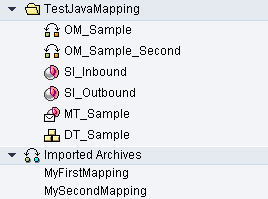






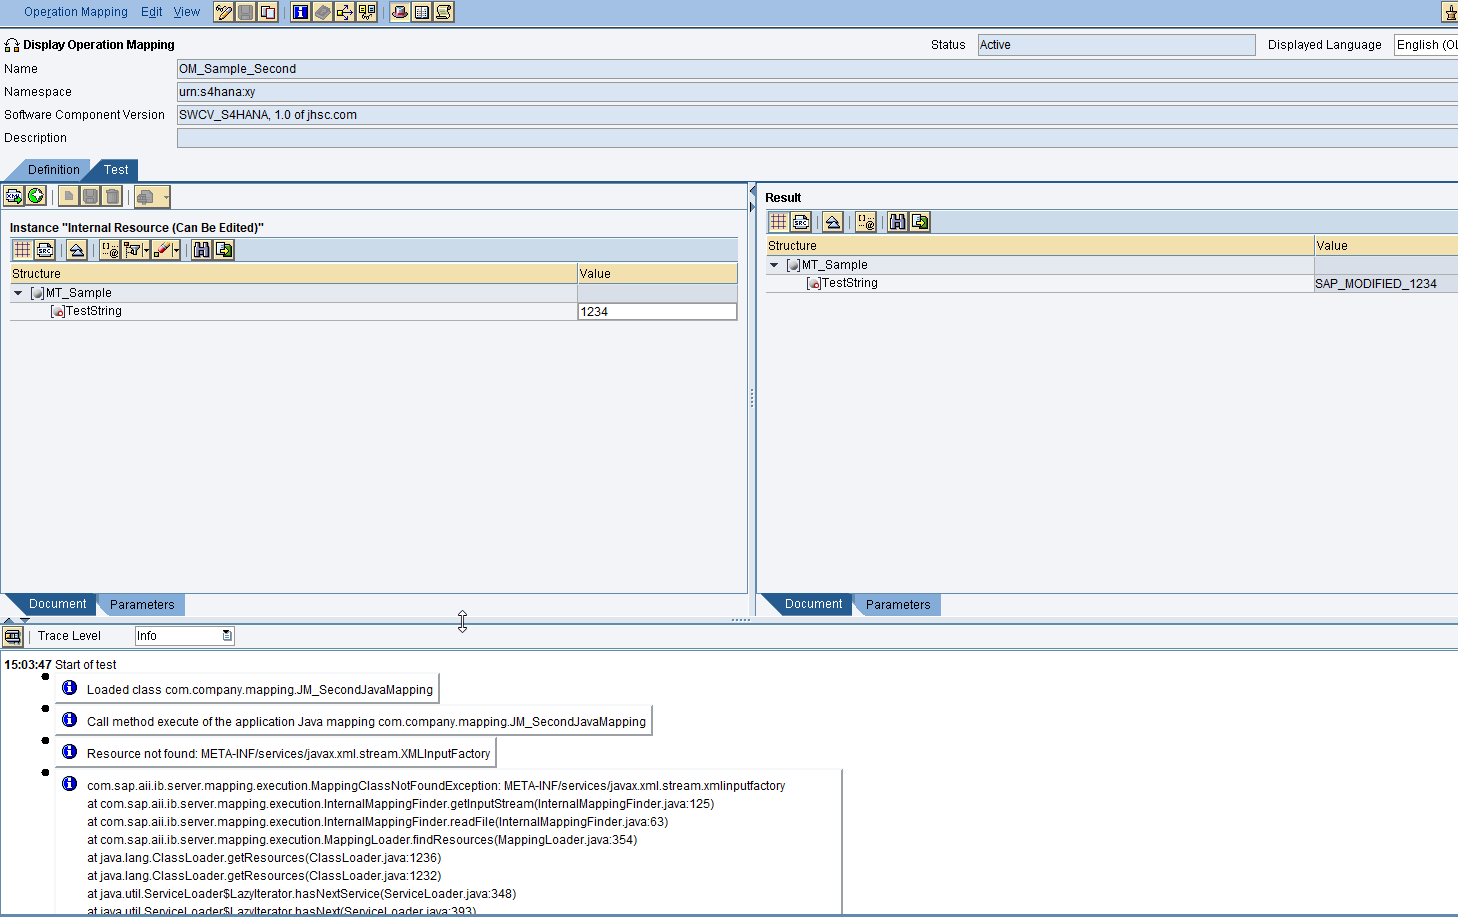

接着造代码






In [ ]:
package com.company.mapping;

import java.io.FileInputStream;
import java.io.FileOutputStream;
import java.io.InputStream;
import java.io.OutputStream;
import java.util.Map;

import javax.xml.stream.XMLInputFactory;
import javax.xml.stream.XMLOutputFactory;
import javax.xml.stream.XMLStreamConstants;
import javax.xml.stream.XMLStreamReader;
import javax.xml.stream.XMLStreamWriter;

import com.sap.aii.mapping.api.AbstractTransformation;
import com.sap.aii.mapping.api.StreamTransformationException;
import com.sap.aii.mapping.api.TransformationInput;
import com.sap.aii.mapping.api.TransformationOutput;

public class JM_SecondJavaMapping extends AbstractTransformation {

    @Override
    public void transform(TransformationInput in, TransformationOutput out) throws StreamTransformationException {
        try {
            execute(in.getInputPayload().getInputStream(), out.getOutputPayload().getOutputStream());
        } catch (Exception ee) {
            throw new StreamTransformationException("Mapping failed: " + ee.getMessage(), ee);
        }
    }

    public void execute(InputStream in, OutputStream out) throws StreamTransformationException {
        try {
            XMLInputFactory factory = XMLInputFactory.newInstance();
            XMLStreamReader reader = factory.createXMLStreamReader(in);
            XMLOutputFactory outFactory = XMLOutputFactory.newInstance();
            XMLStreamWriter writer = outFactory.createXMLStreamWriter(out, "UTF-8");

            writer.writeStartDocument("UTF-8", "1.0");

            String currentElement = null;  // 记录当前正在处理的元素名

            while (reader.hasNext()) {
                int event = reader.next();
                switch (event) {
                    case XMLStreamConstants.START_ELEMENT:
                        // 保存当前元素名，用于后续文本替换判断
                        currentElement = reader.getLocalName();

                        // 正确写入开始元素，包括命名空间和前缀
                        String prefix = reader.getPrefix();
                        String namespaceURI = reader.getNamespaceURI();
                        if (namespaceURI != null) {
                            if (prefix != null && !prefix.isEmpty()) {
                                writer.writeStartElement(prefix, reader.getLocalName(), namespaceURI);
                            } else {
                                writer.writeStartElement(reader.getLocalName(), namespaceURI);
                            }
                        } else {
                            writer.writeStartElement(reader.getLocalName());
                        }

                        // 复制命名空间声明
                        for (int i = 0; i < reader.getNamespaceCount(); i++) {
                            String nsPrefix = reader.getNamespacePrefix(i);
                            String nsURI = reader.getNamespaceURI(i);
                            if (nsPrefix != null && !nsPrefix.isEmpty()) {
                                writer.writeNamespace(nsPrefix, nsURI);
                            } else {
                                writer.writeDefaultNamespace(nsURI);
                            }
                        }

                        // 复制所有属性
                        for (int i = 0; i < reader.getAttributeCount(); i++) {
                            String attPrefix = reader.getAttributePrefix(i);
                            String attLocalName = reader.getAttributeLocalName(i);
                            String attNamespace = reader.getAttributeNamespace(i);
                            String attValue = reader.getAttributeValue(i);
                            if (attNamespace != null) {
                                writer.writeAttribute(attPrefix, attNamespace, attLocalName, attValue);
                            } else {
                                writer.writeAttribute(attLocalName, attValue);
                            }
                        }
                        break;

                    case XMLStreamConstants.CHARACTERS:
//                        String text = reader.getText();
//                        // 只修改 <test> 标签内的非空白文本
//                        if ("test".equals(currentElement) && text != null && text.trim().length() > 0) {
//                            writer.writeCharacters("SAP_MODIFIED_1234");
//                        } else {
//                            writer.writeCharacters(text);
//                        }
                    	String text = reader.getText();
                        // 增加一个判断：不仅看标签名，还要确保它是在 DT_Sample 下面的 TestString
                        if ("TestString".equals(currentElement) && text != null && text.trim().length() > 0) {
                             writer.writeCharacters("SAP_MODIFIED_1234");
                        } else {
                             writer.writeCharacters(text);
                        }
                        break;

                    case XMLStreamConstants.END_ELEMENT:
                        writer.writeEndElement();
                        // 元素结束，清空当前元素标记（防止混合内容干扰）
                        currentElement = null;
                        break;

                    // 以下事件选择性保留，保证输出完整性
                    case XMLStreamConstants.COMMENT:
                        writer.writeComment(reader.getText());
                        break;

                    case XMLStreamConstants.PROCESSING_INSTRUCTION:
                        String pit = reader.getPITarget();
                        String pid = reader.getPIData();
                        if (pid != null) {
                            writer.writeProcessingInstruction(pit, pid);
                        } else {
                            writer.writeProcessingInstruction(pit);
                        }
                        break;

                    case XMLStreamConstants.SPACE:
                        writer.writeCharacters(reader.getText());
                        break;

                    // 其他事件（DTD、实体等）可按需扩展，简单场景先跳过
                    default:
                        break;
                }
            }

            writer.writeEndDocument();
            writer.flush();
            writer.close();
            reader.close();

        } catch (Exception e) {
            throw new StreamTransformationException("XML 处理失败: " + e.getMessage(), e);
        }
    }
    
    
    // --- 本地测试入口 ---
    public static void main(String[] args) {
        try {
            // 确保你项目根目录下有 inputFile.txt
            FileInputStream fin = new FileInputStream("inputFile.txt");
            FileOutputStream fout = new FileOutputStream("outputFile1.txt");

            JM_SecondJavaMapping instance = new JM_SecondJavaMapping();
            instance.execute(fin, fout);

            System.out.println("本地 XML 转换测试成功！请查看 outputFile1.txt");
            fin.close();
            fout.close();
        } catch (Exception ee) {
            ee.printStackTrace();
        }
    }

    // --- 必须实现的抽象方法 ---
    private Map<String, Object> sharedInstance;
    @Override
    public void setSharedInstance(Map<String, Object> map) { this.sharedInstance = map; }
    @Override
    public Map<String, Object> getSharedInstance() { return this.sharedInstance; }
}

In [ ]:
package com.company.mapping;
import java.io.OutputStream;
import java.util.Map;

import com.sap.aii.mapping.api.AbstractTransformation;
import com.sap.aii.mapping.api.StreamTransformationException;
import com.sap.aii.mapping.api.TransformationInput;
import com.sap.aii.mapping.api.TransformationOutput;

public class JM_ParameterizedMapping extends AbstractTransformation {
    public void transform(TransformationInput arg0, TransformationOutput arg1) throws StreamTransformationException {
        try {
            // 读取参数
            String Parameter1 = arg0.getInputParameters().getString("PARAM1");
            String Parameter2 = arg0.getInputParameters().getString("PARAM2");
            String Parameter3 = arg0.getInputParameters().getString("PARAM3");
            
            // 输出结果
            OutputStream out = arg1.getOutputPayload().getOutputStream();
            out.write(("PARAM1 = " + Parameter1 + "\r\n").getBytes());
            out.write(("PARAM2 = " + Parameter2 + "\r\n").getBytes());
            out.write(("PARAM3 = " + Parameter3 + "\r\n").getBytes());
            out.flush();
        } catch(Exception ee) {
            throw new StreamTransformationException(ee.getMessage());
        }
    }

	@Override
	public Map<String, Object> getSharedInstance() {
		// TODO Auto-generated method stub
		return null;
	}

	@Override
	public void setSharedInstance(Map<String, Object> arg0) {
		// TODO Auto-generated method stub
		
	}
}

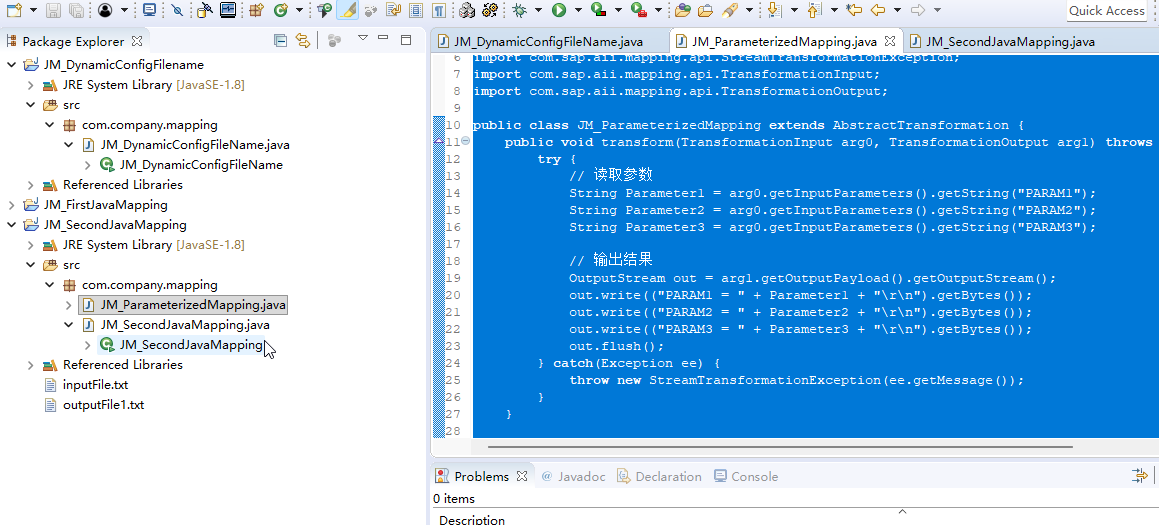



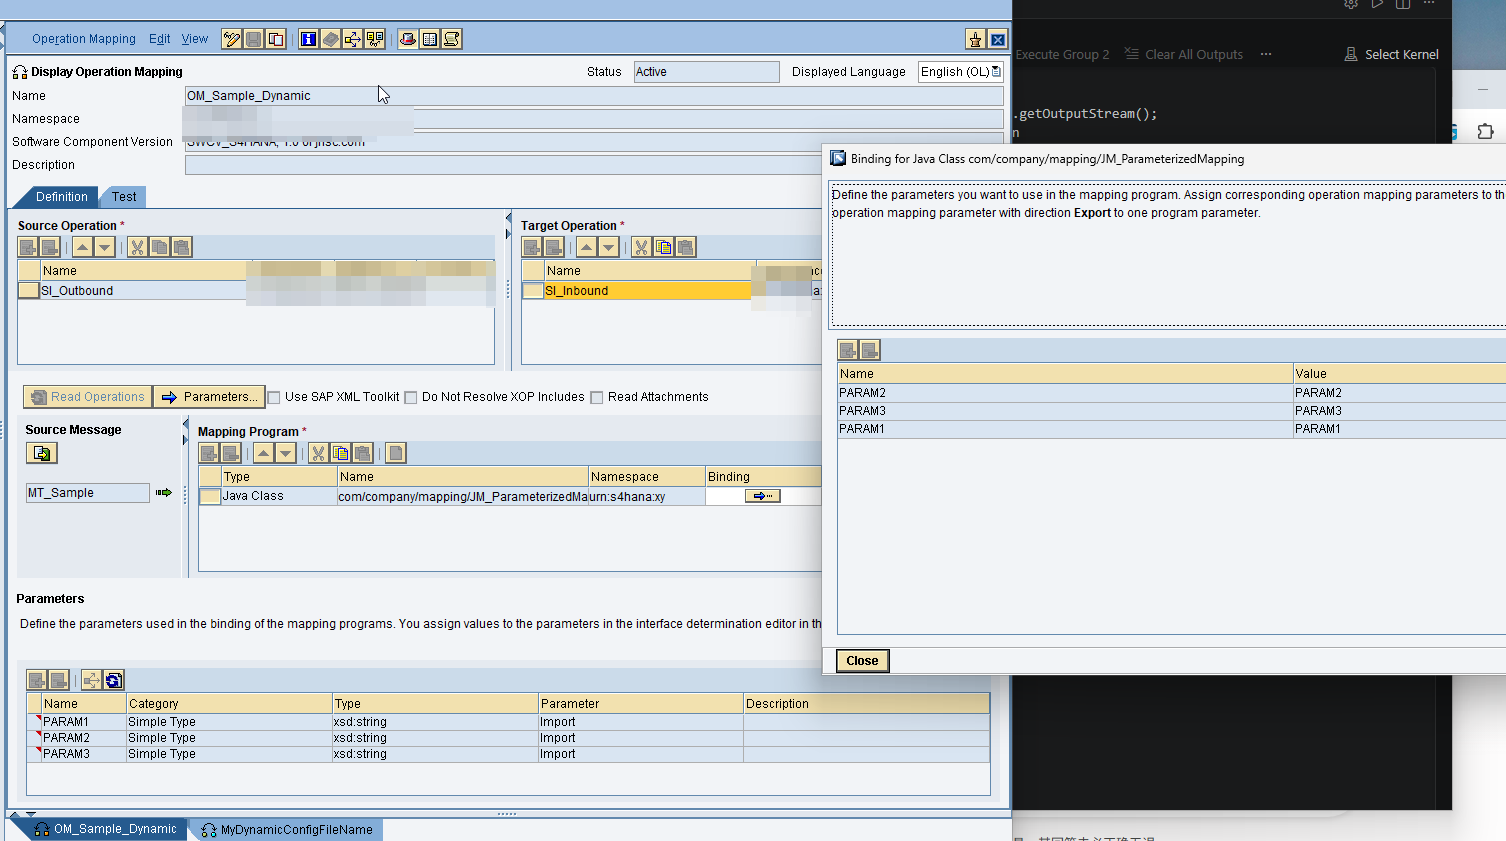


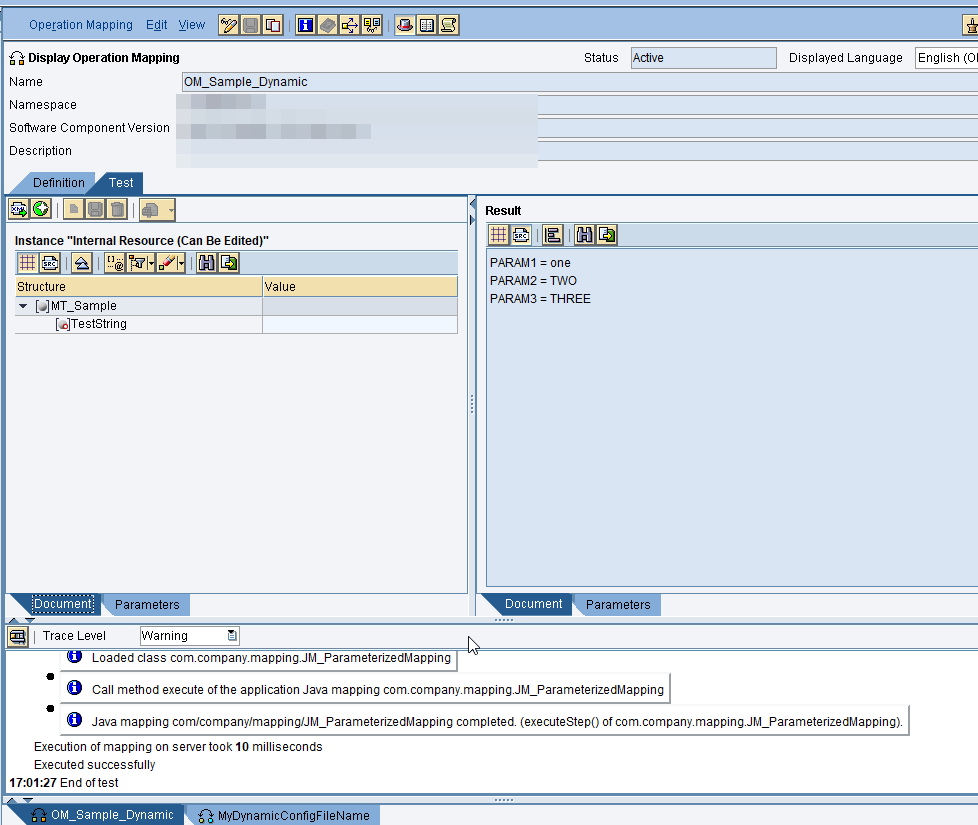


我自己还不知道这个传参有什么用处  比较笨哈哈